
# Reinforcement Learning with Deep Neural Networks (MIT Lecture 5 Companion)
## Value-Based (Q / DQN) and Policy-Based (Policy Gradient / REINFORCE)
### Very elaborative, beginner-friendly, mathematically rigorous + executable code (Colab-ready)

This notebook is written for you as a **slow, careful, step-by-step** bridge between:
- what you already know (loss functions, gradient descent, backprop), and
- what RL changes (the *source of the training signal*).

You specifically mentioned the MIT Lecture 5 “toy car” intuition:
> the untrained car crashes; we retrace backwards from termination and reduce probability of the actions near termination, increase probability of earlier actions, and use that to define a loss and train a neural net.

We will make that intuition **mathematically concrete** and show it in code.

---

## What you’ll learn

1. **MDP** definitions (state, action, reward, discount, trajectory)
2. **Return** $G_t$ and why it creates “credit assignment backwards in time”
3. **Value functions** $V(s)$ and **Q-values** $Q(s,a)$
4. **Value-based RL**: Bellman equation → targets → a regression loss → backprop (DQN style)
5. **Policy-based RL**: log-derivative trick → REINFORCE loss → backprop
6. **Worked numeric example** of the “crash + retrace backwards” effect
7. A simple, fully runnable environment (**LineWorld / ToyCar-1D**) and two training methods:
   - Deep Q-Learning (DQN-like)
   - Policy Gradient (REINFORCE)
8. Simple evaluation + plots to see learning progress

> **Math rendering in Colab:** LaTeX in Markdown (between `$...$` or `$$...$$`) renders properly.



---
# Part A — Start from what you already know

## A1) Supervised learning: where the loss comes from

In supervised learning, you have a dataset of pairs $(x, y)$.
You pick a model $f_\theta$ and a loss $\ell(\cdot)$, e.g. MSE or cross-entropy:

$$
\mathcal{L}(\theta) = \mathbb{E}_{(x,y)} \left[\ell(f_\theta(x), y)\right]
$$

Then you compute its gradient and update parameters:

$$
\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}(\theta)
$$

**Key point:** the target $y$ is given by the dataset.

---

## A2) Reinforcement learning: what changes

In RL, there is **no label** $y$ telling you the correct action.
Instead, you interact with an environment:

At time $t$:
- you observe **state** $s_t$
- your agent chooses an **action** $a_t$
- the environment gives a **reward** $r_t$
- and transitions you to a **next state** $s_{t+1}$

So the “teaching signal” is not a label; it’s a **consequence**.

**Key point:** you must *construct* a learning signal from experience (returns / TD errors / Bellman targets).



---
# Part B — The mathematical framework (MDP)

## B1) Markov Decision Process (MDP)

We model an RL environment as:

$$
(\mathcal{S}, \mathcal{A}, P, R, \gamma)
$$

Where:
- $\mathcal{S}$ = set of possible states
- $\mathcal{A}$ = set of possible actions
- $P(s'|s,a)$ = transition probability to next state $s'$ when taking action $a$ in state $s$
- $R(s,a)$ (or $R(s,a,s')$) = expected immediate reward
- $\gamma \in [0,1)$ = discount factor

### Markov property (why it matters)
The next state depends on the present state and action, not the whole past:

$$
P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, \dots) = P(s_{t+1} | s_t, a_t)
$$

In practice, if you only have partial information, you may use an RNN (or a Transformer) to build a “belief state” / hidden state that becomes Markov-like.

---

## B2) Policy (your neural net as a decision rule)

A **policy** tells you how to choose actions:

$$
\pi(a|s) = P(a_t = a \mid s_t = s)
$$

If $\pi$ is implemented by a neural network with parameters $\theta$, write:

$$
\pi_\theta(a|s)
$$

For discrete actions, the network often outputs **logits** and then softmax to get probabilities.

---

## B3) Trajectories (episodes)

A trajectory (episode) looks like:

$$
\tau = (s_0,a_0,r_0, s_1,a_1,r_1, \dots, s_T)
$$

where $T$ is the terminal time (crash, goal reached, time limit, etc.).



---
# Part C — Returns: the “retrace backwards” math

## C1) Return $G_t$

The **return** from time $t$ is the discounted sum of future rewards:

$$
G_t = \sum_{k=0}^{T-t-1} \gamma^k r_{t+k}
$$

### Why discount?
- It makes sums finite in continuing tasks
- It prioritizes near-term rewards more than far-future rewards
- It stabilizes learning in many settings

---

## C2) This is the exact math behind “retrace backwards”

Suppose your “toy car” crashes at the end with a big negative reward.
Then the last reward influences the return for earlier time steps:

- If the crash reward is $-10$ at time $T-1$,
- then at time $T-2$ the return contains $\gamma(-10)$,
- at time $T-3$ the return contains $\gamma^2(-10)$, etc.

So **earlier actions are still blamed**, but the blame is **discounted** by powers of $\gamma$.

That is literally “retrace backward”: you compute $G_t$ from the end to the beginning:

$$
G_{T-1} = r_{T-1}
$$
$$
G_{T-2} = r_{T-2} + \gamma G_{T-1}
$$
$$
G_{T-3} = r_{T-3} + \gamma G_{T-2}
$$

This backward recursion is how we compute returns efficiently.



---
# Part D — Value functions and Q-values

## D1) State-value function $V^\pi(s)$

The value of a state under a policy $\pi$ is:

$$
V^\pi(s) = \mathbb{E}_\pi[G_t \mid s_t = s]
$$

Interpretation:
- “If I am in state $s$ and follow policy $\pi$ from now on, what long-term return do I expect?”

---

## D2) Action-value function (Q-value) $Q^\pi(s,a)$

$$
Q^\pi(s,a) = \mathbb{E}_\pi[G_t \mid s_t = s, a_t = a]
$$

Interpretation:
- “If I take action $a$ in state $s$, then follow $\pi$, what return do I expect?”

This is the **Q-value** in the MIT lecture.

---

## D3) Advantage function $A^\pi(s,a)$ (very useful later)

$$
A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)
$$

Interpretation:
- How much better (or worse) action $a$ is compared to the average action at state $s$.



---
# Part E — Value-based RL: how DQN creates a loss you can backprop

## E1) Bellman expectation equation (conceptual)

For a given policy $\pi$, the Q-value satisfies:

$$
Q^\pi(s,a) = \mathbb{E}\left[r + \gamma \mathbb{E}_{a'\sim \pi(\cdot|s')} Q^\pi(s',a') \right]
$$

This says:
- The value now equals immediate reward plus discounted value later.

---

## E2) Bellman optimality equation (for the best possible behavior)

The optimal Q-function $Q^*$ satisfies:

$$
Q^*(s,a) = \mathbb{E}\left[r + \gamma \max_{a'} Q^*(s',a')\right]
$$

Now comes the “deep learning part”: we approximate $Q^*$ with a neural network:

$$
Q_\theta(s,a)
$$

---

## E3) The training target (what you compute)

Given a sampled transition $(s_t,a_t,r_t,s_{t+1})$, define a target:

$$
y_t = r_t + \gamma \max_{a'} Q_{\theta^-}(s_{t+1},a')
$$

- $Q_{\theta^-}$ is usually a **target network** (a delayed copy) to stabilize learning.
- If $s_{t+1}$ is terminal, the future term is 0, so $y_t = r_t$.

---

## E4) Loss function (this is the supervised-learning-like part)

You do regression:

$$
\mathcal{L}(\theta) = \left(Q_\theta(s_t,a_t) - y_t\right)^2
$$

Then:
- compute $\nabla_\theta \mathcal{L}$
- backprop through $Q_\theta$
- update weights

So value-based RL often looks like supervised learning **against a moving target** (because $y_t$ uses the model’s own estimates).



---
# Part F — Policy-based RL: the clean math behind “reduce probability of bad steps”

In policy-based RL, you directly learn $\pi_\theta(a|s)$ without explicitly learning a Q-function.

## F1) Objective

We want to maximize expected return:

$$
J(\theta) = \mathbb{E}_{\tau\sim \pi_\theta}[G_0]
$$

## F2) The log-derivative trick (the key step)

A classic identity:

$$
\nabla_\theta p_\theta(x) = p_\theta(x)\nabla_\theta \log p_\theta(x)
$$

Using this and some probability algebra, you can show:

$$
\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t)\; G_t \right]
$$

This is the **policy gradient theorem** (REINFORCE form).

### Interpretation (very important)
For each time step $t$:
- If $G_t$ is **large positive**, increase probability of the chosen action (move policy toward it)
- If $G_t$ is **negative**, decrease probability of the chosen action

Because $G_t$ is computed by “retrace backwards” from the end of the episode, this matches the MIT “toy car” story.

---

## F3) Loss you implement in code

We do gradient descent on the negative objective. A standard loss is:

$$
\mathcal{L}(\theta) = -\sum_{t=0}^{T-1}\log \pi_\theta(a_t|s_t)\; G_t
$$

This is what your deep net backpropagates through.

---

## F4) Why “near termination gets punished more” (your exact confusion)

If a crash happens at the end with a big negative reward:
- the returns **close to the crash** (like $G_{T-1}$, $G_{T-2}$) are very negative
- earlier returns are also negative, but often less negative because:
  - they include earlier step rewards, and
  - the crash is discounted by powers of $\gamma$

Therefore the loss creates larger negative updates for the actions near termination.

That’s the precise mathematical meaning of the lecture’s explanation.



---
# Part G — Worked numeric example of “crash and retrace backwards”

We will do a tiny numeric episode.

Suppose an episode has 4 steps (t=0,1,2,3) and the rewards are:

- $r_0 = -1$ (step cost)
- $r_1 = -1$
- $r_2 = -1$
- $r_3 = -10$ (crash at termination)

Let $\gamma = 0.9$.

Compute returns backwards:

$$
G_3 = r_3 = -10
$$
$$
G_2 = r_2 + 0.9G_3 = -1 + 0.9(-10) = -10
$$
$$
G_1 = r_1 + 0.9G_2 = -1 + 0.9(-10) = -10
$$
$$
G_0 = r_0 + 0.9G_1 = -1 + 0.9(-10) = -10
$$

In this toy, they’re all equally bad. In many environments, rewards differ or termination is not so dominating.

Now see policy loss terms:
$$
\mathcal{L} = -\sum_t \log \pi(a_t|s_t)\; G_t
$$

Since each $G_t$ is negative, the gradient pushes to **decrease** the probabilities of each selected action along the episode.
Often the last actions get the strongest blame (depending on reward structure and discounting).

Let’s compute these numbers with code and print them.


In [1]:

gamma = 0.9
rewards = [-1, -1, -1, -10]

G = 0.0
returns = []
for r in reversed(rewards):
    G = r + gamma * G
    returns.insert(0, G)

print("Rewards:", rewards)
print("Returns:", returns)


Rewards: [-1, -1, -1, -10]
Returns: [-10.0, -10.0, -10.0, -10.0]



---
# Part H — Toy Car environment you can train on (LineWorld / 1D Road)

To make this extremely concrete, we build a tiny environment that captures the car story.

### Environment: LineWorld
- The car starts at position 0.
- The goal is at +5.
- There is a cliff/crash at -5.
- Actions: LEFT (-1) or RIGHT (+1).
- Rewards:
  - +10 if you reach the goal (episode ends)
  - -10 if you fall off the cliff (episode ends)
  - -1 per step otherwise (encourages short solutions)

This is small enough to fully understand, but still demonstrates:
- Q-values and Bellman targets (value-based RL)
- Return-based probability updates (policy-based RL)


In [2]:

import numpy as np

class LineWorld:
    def __init__(self, goal=5, cliff=-5, max_steps=30):
        self.goal = goal
        self.cliff = cliff
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.pos = 0
        self.t = 0
        return np.array([self.pos], dtype=np.float32)

    def step(self, action):
        # action: 0=left, 1=right
        move = -1 if action == 0 else 1
        self.pos += move
        self.t += 1

        # terminal checks
        if self.pos >= self.goal:
            return np.array([self.pos], dtype=np.float32), 10.0, True, {"terminal": "goal"}
        if self.pos <= self.cliff:
            return np.array([self.pos], dtype=np.float32), -10.0, True, {"terminal": "cliff"}
        if self.t >= self.max_steps:
            return np.array([self.pos], dtype=np.float32), -1.0, True, {"terminal": "timeout"}

        return np.array([self.pos], dtype=np.float32), -1.0, False, {}

env = LineWorld()
s = env.reset()
print("start state:", s)
for a in [1,1,1]:
    s, r, done, info = env.step(a)
    print("action", a, "-> state", s, "reward", r, "done", done, info)


start state: [0.]
action 1 -> state [1.] reward -1.0 done False {}
action 1 -> state [2.] reward -1.0 done False {}
action 1 -> state [3.] reward -1.0 done False {}



---
# Part I — Value-Based RL in code: Deep Q-Learning (DQN-like)

## I1) What the network represents
We create a neural network that takes state $s$ and outputs Q-values for each action:

$$
Q_\theta(s,\cdot) = [Q_\theta(s,0), Q_\theta(s,1)]
$$

## I2) What you compute each step
You sample a transition $(s,a,r,s')$ by interacting with the environment, then compute:

1) prediction: $Q_\theta(s,a)$  
2) target: $y = r + \gamma\max_{a'} Q_{\theta^-}(s',a')$  
3) loss: $(Q_\theta(s,a) - y)^2$  
4) backprop + update $\theta$

We’ll also do:
- epsilon-greedy exploration
- replay buffer
- target network updates


In [3]:

import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

class QNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # two actions
        )
    def forward(self, s):
        return self.net(s)

q = QNet()
q_target = QNet()
q_target.load_state_dict(q.state_dict())

opt = optim.Adam(q.parameters(), lr=1e-3)

gamma = 0.99
replay = deque(maxlen=5000)

def epsilon_by_step(step, eps_start=1.0, eps_end=0.05, eps_decay=2000):
    # linear decay
    if step >= eps_decay:
        return eps_end
    return eps_start + (eps_end - eps_start) * (step / eps_decay)

def dqn_train(num_episodes=1200, batch_size=64, target_update=250):
    returns = []
    global_step = 0

    for ep in range(1, num_episodes + 1):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            eps = epsilon_by_step(global_step)
            global_step += 1

            # choose action
            if random.random() < eps:
                a = random.randint(0, 1)
            else:
                with torch.no_grad():
                    s_t = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
                    a = int(torch.argmax(q(s_t), dim=-1).item())

            s2, r, done, info = env.step(a)
            ep_return += r

            replay.append((s, a, r, s2, done))
            s = s2

            # learn from replay
            if len(replay) >= batch_size:
                batch = random.sample(replay, batch_size)
                s_b  = torch.tensor([b[0] for b in batch], dtype=torch.float32)
                a_b  = torch.tensor([b[1] for b in batch], dtype=torch.int64)
                r_b  = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                s2_b = torch.tensor([b[3] for b in batch], dtype=torch.float32)
                d_b  = torch.tensor([b[4] for b in batch], dtype=torch.float32)

                # Q(s,a)
                q_sa = q(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)

                # target y = r + gamma * max_a' Q_target(s', a') (if not done)
                with torch.no_grad():
                    max_next = q_target(s2_b).max(dim=1).values
                    y = r_b + gamma * (1.0 - d_b) * max_next

                loss = (q_sa - y).pow(2).mean()

                opt.zero_grad()
                loss.backward()
                opt.step()

                if global_step % target_update == 0:
                    q_target.load_state_dict(q.state_dict())

        returns.append(ep_return)

        if ep % 100 == 0:
            print(f"Episode {ep:4d} | avg return (last 100): {np.mean(returns[-100:]):7.3f} | eps={eps:.3f}")

    return returns

dqn_returns = dqn_train()


/tmp/ipython-input-667/1120337894.py:67: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  s_b  = torch.tensor([b[0] for b in batch], dtype=torch.float32)


Episode  100 | avg return (last 100):  -4.220 | eps=0.361
Episode  200 | avg return (last 100):   4.820 | eps=0.067
Episode  300 | avg return (last 100):   5.840 | eps=0.050
Episode  400 | avg return (last 100):   5.780 | eps=0.050
Episode  500 | avg return (last 100):   5.700 | eps=0.050
Episode  600 | avg return (last 100):   5.780 | eps=0.050
Episode  700 | avg return (last 100):   5.920 | eps=0.050
Episode  800 | avg return (last 100):   5.660 | eps=0.050
Episode  900 | avg return (last 100):   5.740 | eps=0.050
Episode 1000 | avg return (last 100):   5.740 | eps=0.050
Episode 1100 | avg return (last 100):   5.780 | eps=0.050
Episode 1200 | avg return (last 100):   5.920 | eps=0.050



### I3) Evaluate DQN policy (greedy)

We run the learned policy greedily (always take the action with highest Q-value) and print the trajectory.


In [4]:

def run_greedy_dqn(max_steps=30):
    s = env.reset()
    done = False
    path = [int(s[0])]
    total = 0.0
    steps = 0

    while not done and steps < max_steps:
        with torch.no_grad():
            s_t = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
            a = int(torch.argmax(q(s_t), dim=-1).item())
        s, r, done, info = env.step(a)
        total += r
        steps += 1
        path.append(int(s[0]))

    return total, steps, path, info if done else {}

for i in range(5):
    total, steps, path, info = run_greedy_dqn()
    print(f"Trial {i+1}: return={total}, steps={steps}, terminal={info.get('terminal', None)}, path={path}")


Trial 1: return=6.0, steps=5, terminal=goal, path=[0, 1, 2, 3, 4, 5]
Trial 2: return=6.0, steps=5, terminal=goal, path=[0, 1, 2, 3, 4, 5]
Trial 3: return=6.0, steps=5, terminal=goal, path=[0, 1, 2, 3, 4, 5]
Trial 4: return=6.0, steps=5, terminal=goal, path=[0, 1, 2, 3, 4, 5]
Trial 5: return=6.0, steps=5, terminal=goal, path=[0, 1, 2, 3, 4, 5]



---
# Part J — Policy-Based RL in code: REINFORCE (the “toy car retrace backward” algorithm)

Here we learn a neural network policy $\pi_\theta(a|s)$.

## J1) What you compute in REINFORCE

For one episode:
1) Collect $(s_t, a_t, r_t)$ for all steps
2) Compute returns $G_t$ by retracing backward
3) Compute loss:

$$
\mathcal{L}(\theta) = -\sum_t \log \pi_\theta(a_t|s_t)\; G_t
$$

4) Backprop and update $\theta$

### Important beginner note (variance reduction)
Raw returns can have high variance. A common trick is to normalize returns (mean 0, std 1) or subtract a baseline.
We’ll normalize returns to make training more stable and easier to see.


In [5]:

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, s):
        logits = self.net(s)
        return torch.softmax(logits, dim=-1)

policy = PolicyNet()
opt_pg = optim.Adam(policy.parameters(), lr=2e-3)
gamma = 0.99

def reinforce_train(num_episodes=2000):
    returns_history = []

    for ep in range(1, num_episodes + 1):
        s = env.reset()
        done = False

        logps = []
        rewards = []

        while not done:
            s_t = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
            probs = policy(s_t).squeeze(0)
            dist = torch.distributions.Categorical(probs=probs)
            a = dist.sample()

            s2, r, done, info = env.step(int(a.item()))

            logps.append(dist.log_prob(a))
            rewards.append(r)

            s = s2

        # retrace backward to compute returns G_t
        G = 0.0
        Gs = []
        for r in reversed(rewards):
            G = r + gamma * G
            Gs.insert(0, G)

        Gs = torch.tensor(Gs, dtype=torch.float32)

        # normalize returns for stability
        Gs = (Gs - Gs.mean()) / (Gs.std() + 1e-8)

        # policy loss
        loss = 0.0
        for logp, Gt in zip(logps, Gs):
            loss += -logp * Gt

        opt_pg.zero_grad()
        loss.backward()
        opt_pg.step()

        ep_return = sum(rewards)
        returns_history.append(ep_return)

        if ep % 200 == 0:
            print(f"Episode {ep:4d} | avg return (last 200): {np.mean(returns_history[-200:]):7.3f}")

    return returns_history

pg_returns = reinforce_train()


Episode  200 | avg return (last 200): -15.070
Episode  400 | avg return (last 200): -14.200
Episode  600 | avg return (last 200): -14.130
Episode  800 | avg return (last 200): -13.760
Episode 1000 | avg return (last 200): -13.430
Episode 1200 | avg return (last 200): -12.910
Episode 1400 | avg return (last 200): -10.450
Episode 1600 | avg return (last 200): -12.010
Episode 1800 | avg return (last 200): -13.030
Episode 2000 | avg return (last 200): -13.200



### J2) Evaluate the learned policy (greedy / most-probable action)

We take the action with maximum probability at each step and see if it reaches the goal reliably.


In [6]:

def run_greedy_policy(max_steps=30):
    s = env.reset()
    done = False
    path = [int(s[0])]
    total = 0.0
    steps = 0
    info = {}

    while not done and steps < max_steps:
        with torch.no_grad():
            s_t = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
            probs = policy(s_t).squeeze(0)
            a = int(torch.argmax(probs).item())
        s, r, done, info = env.step(a)
        total += r
        steps += 1
        path.append(int(s[0]))

    return total, steps, path, info if done else {}

for i in range(5):
    total, steps, path, info = run_greedy_policy()
    print(f"Trial {i+1}: return={total}, steps={steps}, terminal={info.get('terminal', None)}, path={path}")


Trial 1: return=-14.0, steps=5, terminal=cliff, path=[0, -1, -2, -3, -4, -5]
Trial 2: return=-14.0, steps=5, terminal=cliff, path=[0, -1, -2, -3, -4, -5]
Trial 3: return=-14.0, steps=5, terminal=cliff, path=[0, -1, -2, -3, -4, -5]
Trial 4: return=-14.0, steps=5, terminal=cliff, path=[0, -1, -2, -3, -4, -5]
Trial 5: return=-14.0, steps=5, terminal=cliff, path=[0, -1, -2, -3, -4, -5]



---
# Part K — Visualize learning curves (optional but helpful)

We’ll plot episode returns for both approaches so you can *see* the improvement.


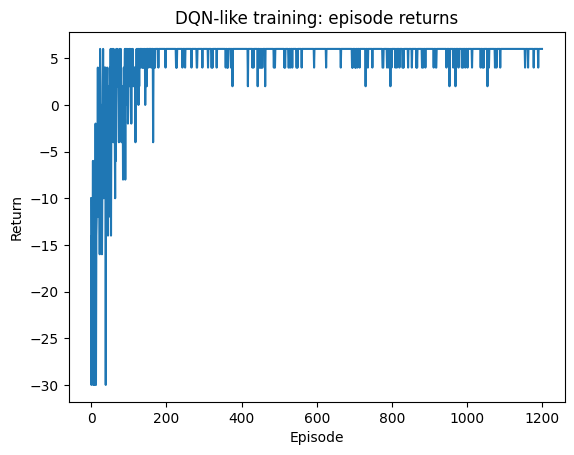

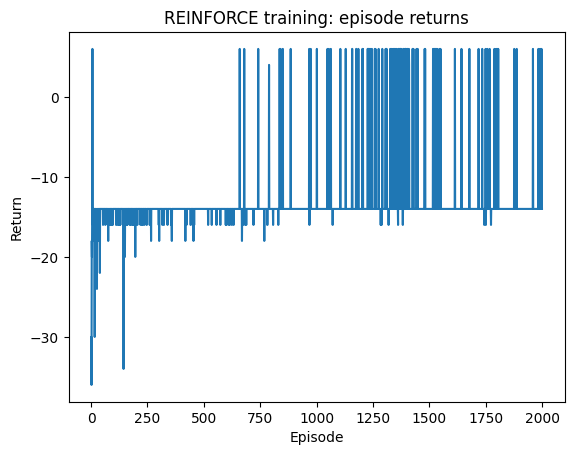

In [7]:

import matplotlib.pyplot as plt

plt.figure()
plt.plot(dqn_returns)
plt.title("DQN-like training: episode returns")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

plt.figure()
plt.plot(pg_returns)
plt.title("REINFORCE training: episode returns")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()



---
# Part L — Summary (in your words)

### Value-based RL (Q-learning / DQN):
- Learn a network $Q_\theta(s,a)$ that predicts how good each action is.
- Build a “label-like” target using Bellman equation:
  $$y = r + \gamma \max_{a'} Q_{\theta^-}(s',a')$$
- Minimize squared error:
  $$\left(Q_\theta(s,a) - y\right)^2$$
- Backprop updates $Q_\theta$.

### Policy-based RL (REINFORCE):
- Learn a network policy $\pi_\theta(a|s)$ (probabilities of actions).
- Run an episode, crash or reach goal.
- **Retrace backward** to compute returns $G_t$.
- Update probabilities using:
  $$\mathcal{L}(\theta) = -\sum_t \log \pi_\theta(a_t|s_t)\; G_t$$

This is exactly the MIT “reduce probability of steps near termination” idea:
- If $G_t$ is negative, that step’s chosen action probability is pushed down.
- Because $G_t$ comes from future rewards and is computed backward, later failures assign blame backward in time.

---

## Next step (if you want):
I can extend this notebook to include:
- **Baseline / Advantage** derivation (lower variance, closer to modern actor-critic)
- **Actor–Critic** implementation (policy + value network together)
- A 2D “road” environment (left/right choices), closer to the lecture’s toy car lane setting
- PPO-style clipped objective (the common RLHF method)
